In [ ]:
# =========================================================
# 0. Library Import & Environment Setup
# =========================================================
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# SHAP optional
try:
    import shap
    SHAP_AVAILABLE = True
except:
    SHAP_AVAILABLE = False

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Google Drive mount
drive.mount('/content/drive')

# Base path
BASE_PATH = "/content/drive/MyDrive/FinGuard"
DATA_PATH = f"{BASE_PATH}/card_transdata.csv"
IMAGE_PATH = f"{BASE_PATH}/images"
MODEL_PATH = f"{BASE_PATH}/models"

os.makedirs(IMAGE_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

plt.rcParams["figure.dpi"] = 120

print("BASE_PATH:", BASE_PATH)
print("DATA_PATH:", DATA_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE_PATH: /content/drive/MyDrive/FinGuard
DATA_PATH: /content/drive/MyDrive/FinGuard/card_transdata.csv


In [ ]:
# =========================================================
# 1. Data Loading
# =========================================================
df = pd.read_csv(DATA_PATH)

print("데이터 크기:", df.shape)
print("\n상위 5개 행")
display(df.head())

print("\n컬럼 목록")
print(df.columns.tolist())

데이터 크기: (1000000, 8)

상위 5개 행


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0



컬럼 목록
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'fraud']


In [ ]:
# =========================================================
# 2. Column Setting
# =========================================================
target_col = "fraud"

feature_cols = [
    "distance_from_home",
    "distance_from_last_transaction",
    "ratio_to_median_purchase_price",
    "repeat_retailer",
    "used_chip"
]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\n타겟 분포")
print(y.value_counts())
print("\n타겟 비율")
print(y.value_counts(normalize=True).round(4))

Feature shape: (1000000, 5)
Target shape: (1000000,)

타겟 분포
fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

타겟 비율
fraud
0.0    0.9126
1.0    0.0874
Name: proportion, dtype: float64


[결측치 확인]


,0
distance_from_home,0
distance_from_last_transaction,0
ratio_to_median_purchase_price,0
repeat_retailer,0
used_chip,0
fraud,0


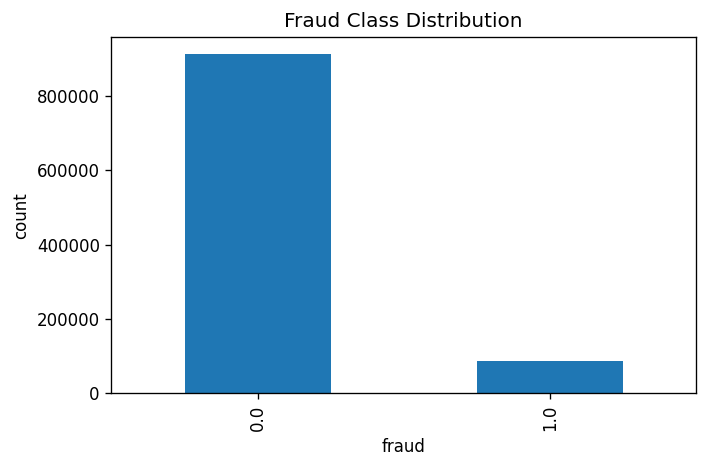

In [ ]:
# =========================================================
# 3. Basic EDA
# =========================================================
print("[결측치 확인]")
display(df[feature_cols + [target_col]].isnull().sum())

# 클래스 분포 시각화
fig, ax = plt.subplots(figsize=(6, 4))
y.value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Fraud Class Distribution")
ax.set_xlabel("fraud")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig(f"{IMAGE_PATH}/class_distribution.png", bbox_inches="tight")
plt.show()

In [ ]:
# =========================================================
# 4. Train / Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\n[Train class ratio]")
print(y_train.value_counts(normalize=True).round(4))

print("\n[Test class ratio]")
print(y_test.value_counts(normalize=True).round(4))

X_train: (800000, 5)
X_test : (200000, 5)
y_train: (800000,)
y_test : (200000,)

[Train class ratio]
fraud
0.0    0.9126
1.0    0.0874
Name: proportion, dtype: float64

[Test class ratio]
fraud
0.0    0.9126
1.0    0.0874
Name: proportion, dtype: float64


In [ ]:
# =========================================================
# 5. Baseline Model
# =========================================================
baseline_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=SEED
)

baseline_model.fit(X_train, y_train)

y_proba_base = baseline_model.predict_proba(X_test)[:, 1]
y_pred_base = (y_proba_base >= 0.5).astype(int)

baseline_metrics = {
    "Setting": "Baseline",
    "Threshold": 0.5,
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "Precision": precision_score(y_test, y_pred_base, zero_division=0),
    "Recall": recall_score(y_test, y_pred_base, zero_division=0),
    "F1": f1_score(y_test, y_pred_base, zero_division=0),
}

print("[Baseline Metrics]")
for k, v in baseline_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\n[Baseline Classification Report]")
print(classification_report(y_test, y_pred_base, zero_division=0))

[Baseline Metrics]
Setting: Baseline
Threshold: 0.5000
Accuracy: 0.9453
Precision: 0.6200
Recall: 0.9674
F1: 0.7557

[Baseline Classification Report]
              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97    182519
         1.0       0.62      0.97      0.76     17481

    accuracy                           0.95    200000
   macro avg       0.81      0.96      0.86    200000
weighted avg       0.96      0.95      0.95    200000



In [ ]:
# =========================================================
# 6. Imbalance Handling (SMOTE + UnderSampling)
# =========================================================
print("[Before Resampling]")
print(y_train.value_counts())

resampling_pipeline = Pipeline([
    ("smote", SMOTE(random_state=SEED)),
    ("under", RandomUnderSampler(random_state=SEED))
])

X_resampled, y_resampled = resampling_pipeline.fit_resample(X_train, y_train)

print("\n[After Resampling]")
print(pd.Series(y_resampled).value_counts())

[Before Resampling]
fraud
0.0    730078
1.0     69922
Name: count, dtype: int64

[After Resampling]
fraud
0.0    730078
1.0    730078
Name: count, dtype: int64


In [ ]:
# =========================================================
# 7. Resampled Model Training
# =========================================================
resampled_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=SEED
)

resampled_model.fit(X_resampled, y_resampled)

y_proba_resampled = resampled_model.predict_proba(X_test)[:, 1]
y_pred_resampled_05 = (y_proba_resampled >= 0.5).astype(int)

resampled_metrics_05 = {
    "Setting": "Resampled",
    "Threshold": 0.5,
    "Accuracy": accuracy_score(y_test, y_pred_resampled_05),
    "Precision": precision_score(y_test, y_pred_resampled_05, zero_division=0),
    "Recall": recall_score(y_test, y_pred_resampled_05, zero_division=0),
    "F1": f1_score(y_test, y_pred_resampled_05, zero_division=0),
}

print("[Resampled Metrics @ 0.5]")
for k, v in resampled_metrics_05.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\n[Resampled Classification Report @ 0.5]")
print(classification_report(y_test, y_pred_resampled_05, zero_division=0))

[Resampled Metrics @ 0.5]
Setting: Resampled
Threshold: 0.5000
Accuracy: 0.9427
Precision: 0.6044
Recall: 0.9983
F1: 0.7529

[Resampled Classification Report @ 0.5]
              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97    182519
         1.0       0.60      1.00      0.75     17481

    accuracy                           0.94    200000
   macro avg       0.80      0.97      0.86    200000
weighted avg       0.97      0.94      0.95    200000



In [ ]:
# =========================================================
# 8. Threshold Tuning
# =========================================================
thresholds = np.arange(0.1, 1.0, 0.1)

threshold_results = []
for t in thresholds:
    y_pred_t = (y_proba_resampled >= t).astype(int)
    threshold_results.append({
        "Threshold": round(float(t), 2),
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall": recall_score(y_test, y_pred_t, zero_division=0),
        "F1": f1_score(y_test, y_pred_t, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df.round(4))

,Threshold,Accuracy,Precision,Recall,F1
0,0.1,0.9420,0.6012,1.0000,0.7510
1,0.2,0.9421,0.6014,0.9999,0.7511
2,0.3,0.9422,0.6020,0.9996,0.7515
3,0.4,0.9424,0.6028,0.9993,0.7519
4,0.5,0.9427,0.6044,0.9983,0.7529
5,0.6,0.9439,0.6096,0.9947,0.7560
6,0.7,0.9453,0.6166,0.9887,0.7596
7,0.8,0.9456,0.6195,0.9795,0.7590
8,0.9,0.9445,0.6216,0.9324,0.7459


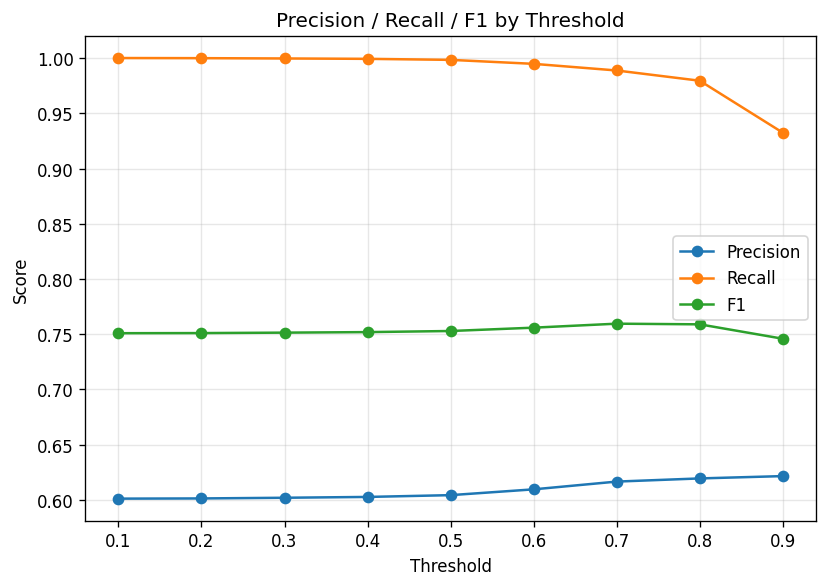

In [ ]:
# =========================================================
# 9. Threshold Metrics Plot
# =========================================================
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
ax.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
ax.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 by Threshold")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(f"{IMAGE_PATH}/threshold_metrics.png", bbox_inches="tight")
plt.show()

In [ ]:
# =========================================================
# 10. Select Final Threshold
# =========================================================
# threshold_df 결과를 보고 원하는 값으로 조정
final_threshold = 0.8

y_pred_final = (y_proba_resampled >= final_threshold).astype(int)

final_metrics = {
    "Setting": "Final Model",
    "Threshold": final_threshold,
    "Accuracy": accuracy_score(y_test, y_pred_final),
    "Precision": precision_score(y_test, y_pred_final, zero_division=0),
    "Recall": recall_score(y_test, y_pred_final, zero_division=0),
    "F1": f1_score(y_test, y_pred_final, zero_division=0),
}

print("[Final Metrics]")
for k, v in final_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\n[Final Classification Report]")
print(classification_report(y_test, y_pred_final, zero_division=0))

[Final Metrics]
Setting: Final Model
Threshold: 0.8000
Accuracy: 0.9456
Precision: 0.6195
Recall: 0.9795
F1: 0.7590

[Final Classification Report]
              precision    recall  f1-score   support

         0.0       1.00      0.94      0.97    182519
         1.0       0.62      0.98      0.76     17481

    accuracy                           0.95    200000
   macro avg       0.81      0.96      0.86    200000
weighted avg       0.96      0.95      0.95    200000



In [ ]:
# =========================================================
# 11. Summary Table for README
# =========================================================
summary_df = pd.DataFrame([
    baseline_metrics,
    resampled_metrics_05,
    final_metrics
])

display(summary_df.round(4))

,Setting,Threshold,Accuracy,Precision,Recall,F1
0,Baseline,0.5,0.9453,0.6200,0.9674,0.7557
1,Resampled,0.5,0.9427,0.6044,0.9983,0.7529
2,Final Model,0.8,0.9456,0.6195,0.9795,0.7590


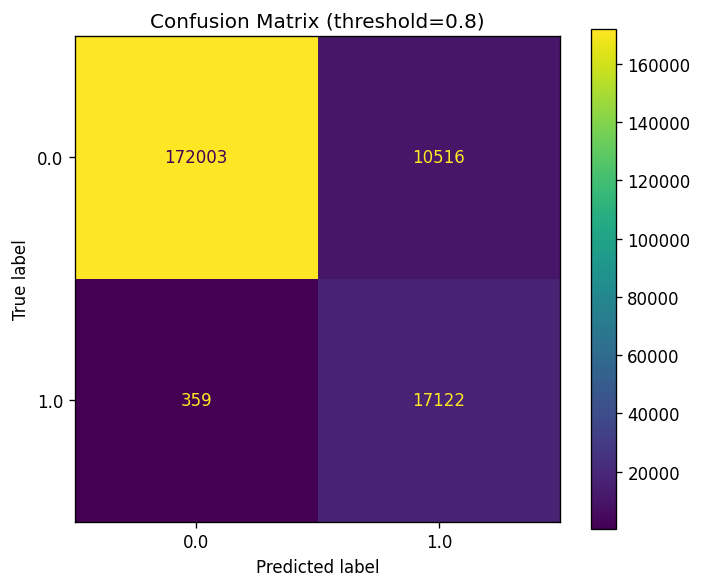

In [ ]:
# =========================================================
# 12. Confusion Matrix
# =========================================================
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    ax=ax,
    values_format="d"
)
ax.set_title(f"Confusion Matrix (threshold={final_threshold})")
plt.tight_layout()
plt.savefig(f"{IMAGE_PATH}/confusion_matrix.png", bbox_inches="tight")
plt.show()

,feature,importance
2,ratio_to_median_purchase_price,0.571756
0,distance_from_home,0.231548
1,distance_from_last_transaction,0.088865
4,used_chip,0.074644
3,repeat_retailer,0.033187


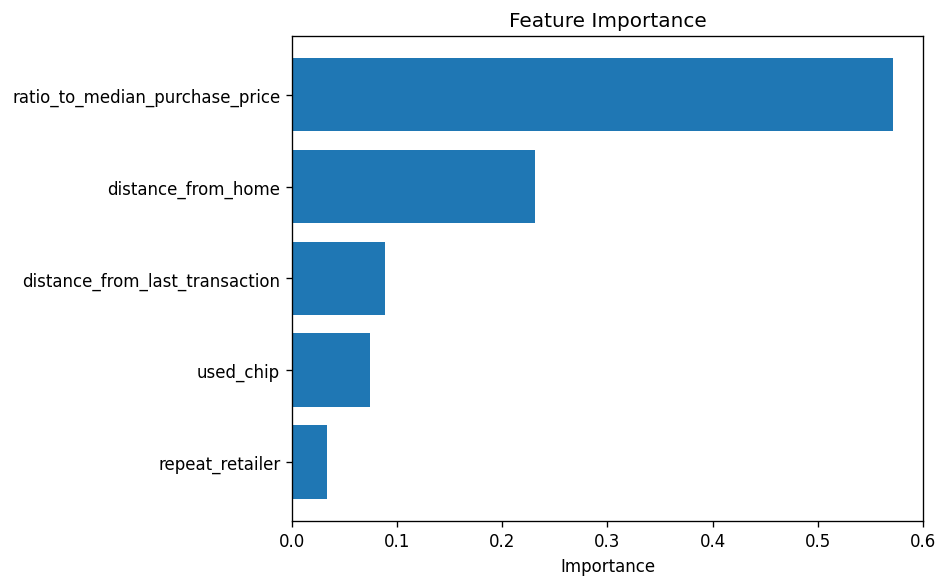

In [ ]:
# =========================================================
# 13. Feature Importance
# =========================================================
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": resampled_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df)

plot_df = importance_df.head(10).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_df["feature"], plot_df["importance"])
ax.set_xlabel("Importance")
ax.set_title("Feature Importance")
plt.tight_layout()
plt.savefig(f"{IMAGE_PATH}/feature_importance.png", bbox_inches="tight")
plt.show()

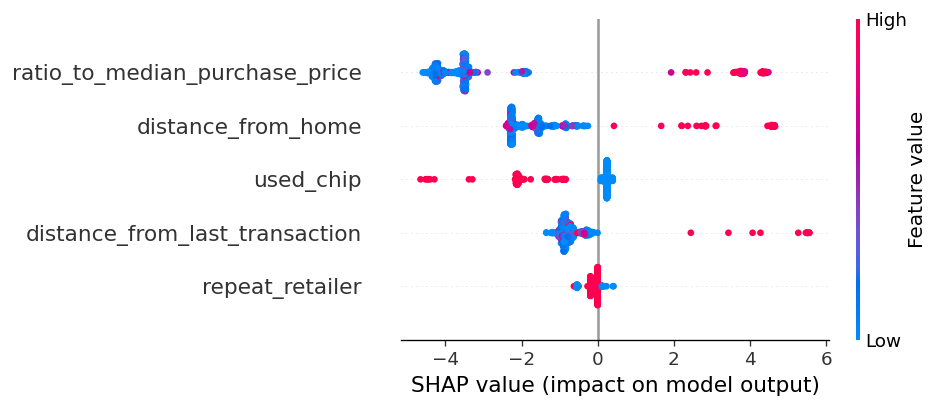

In [ ]:
# =========================================================
# 14. SHAP Summary Plot (Optional)
# =========================================================
if SHAP_AVAILABLE:
    sample_X = X_test.sample(min(500, len(X_test)), random_state=SEED)
    explainer = shap.TreeExplainer(resampled_model)
    shap_values = explainer.shap_values(sample_X)

    shap.summary_plot(shap_values, sample_X, show=False)
    plt.tight_layout()
    plt.savefig(f"{IMAGE_PATH}/shap_summary.png", bbox_inches="tight")
    plt.show()
else:
    print("SHAP is not installed. This step was skipped.")

In [ ]:
# =========================================================
# 15. Save Final Model
# =========================================================
save_obj = {
    "model": resampled_model,
    "threshold": final_threshold,
    "features": feature_cols
}

joblib.dump(save_obj, f"{MODEL_PATH}/xgb_threshold_model.pkl")
print(f"Saved model to: {MODEL_PATH}/xgb_threshold_model.pkl")

Saved model to: /content/drive/MyDrive/FinGuard/models/xgb_threshold_model.pkl


In [ ]:
# =========================================================
# 16. Save Metrics CSV (Optional)
# =========================================================
summary_df.to_csv(f"{BASE_PATH}/summary_metrics.csv", index=False)
threshold_df.to_csv(f"{BASE_PATH}/threshold_metrics_table.csv", index=False)

print(f"Saved summary table to: {BASE_PATH}/summary_metrics.csv")
print(f"Saved threshold table to: {BASE_PATH}/threshold_metrics_table.csv")

Saved summary table to: /content/drive/MyDrive/FinGuard/summary_metrics.csv
Saved threshold table to: /content/drive/MyDrive/FinGuard/threshold_metrics_table.csv
